# ARMS benchmark interactive segmentation

Belgium ↔ Crete, 8-class union, plate-disjoint splits. All numbers are **v15**; every cell is a
10-seed mean ± std over random prompt draws.

Six models, all base-size, each fine-tuned by its own published recipe:

| | family | input | what is fine-tuned |
|---|---|---|---|
| SAM-1-B | generalist | 1024 | mask decoder (4.06M) |
| HQ-SAM-B | generalist | 1024 | HQ module only (1.07M) |
| SAM2-B+ | generalist | 1024 | mask decoder (4.22M) |
| OSISeg-B | generalist | 512 | encoder adapters + decoder (14.75M) |
| SegNext | specialist | 1024 | neck + head + fusion (25.0M) |
| SimpleClick | specialist | 448 | neck + head (11.0M) |

**Trainable capacity spans 23×** because each model follows its authors' recipe. Differences between
fine-tuned rows therefore reflect recipe and capacity as well as architecture.

**Noise floor: 0.59 macro IoU**, measured from three independent training runs on identical data.
Differences smaller than that are not distinguishable.

### Functions

In [1]:
import json
from pathlib import Path
from collections import defaultdict
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

METRIC = "macro"          # "macro" (class-averaged, rare-class-fair) | "micro" (instance-pooled)
BASE   = Path("..")
V15    = BASE / "outputs/v15"
SITES  = ["Belgium", "Crete"]
REGIMES = ["Belgium", "Crete", "combined"]
STRATS = ["click_1pt", "bbox_noisy"]
PRETTY = {"click_1pt": "click", "bbox_noisy": "box", "skely_K6": "skely", "random_K6": "random"}
GRAD   = "RdYlGn"

# (label, family tag, generalist?), base-size models only
MODELS = [("SAM-1-B", "sam1_vit_b", True), ("HQ-SAM-B", "hqsam_vit_b", True),
          ("SAM2-B+", "sam2_hiera_b", True), ("OSISeg-B", "osiseg_b", True),
          ("SegNext", "segnext", False), ("SimpleClick", "simpleclick", False)]
BB_OF = {lbl: bb for lbl, bb, _ in MODELS}
IS_GEN = {bb: g for _, bb, g in MODELS}

XEVAL_ORDER = [("Belgium", "Belgium"), ("Crete", "Belgium"), ("combined", "Belgium"),
               ("Crete", "Crete"), ("Belgium", "Crete"), ("combined", "Crete")]
BLOCKS = [XEVAL_ORDER[:3], XEVAL_ORDER[3:]]          # grouped by eval site

# ---------------------------------------------------------------- accessors
def path_of(bb, reg, site, tag=""):
    """One result file. Generalists live in multieval/, specialists in specialist/."""
    if IS_GEN[bb]:
        return V15 / f"multieval/v12me_{reg}_on_{site}_{bb}{tag}.json"
    return V15 / f"specialist/v15sp_species_{reg}_on_{site}_{bb}{tag}.json"

def _strat(bb, reg, site, strat, tag=""):
    f = path_of(bb, reg, site, tag)
    if not f.exists():
        return {}
    return json.load(open(f))["strategies"].get(strat, {})

def sam_ms(bb, reg, site, strat, tag=""):
    """(mean, std) IoU under the active METRIC. Macro is rebuilt per seed from the
    per-class table, so it is defined the same way for every model."""
    d = _strat(bb, reg, site, strat, tag)
    if not d:
        return (np.nan, 0.0)
    if METRIC == "micro":
        return (d.get("mean", np.nan), d.get("std", 0.0))
    per = [float(np.mean(list(s.values()))) for s in d.get("per_class_per_seed", []) if s]
    if not per:
        return (np.nan, 0.0)
    return (float(np.mean(per)), float(np.std(per, ddof=1)) if len(per) > 1 else 0.0)

def sam_perclass(bb, reg, site, strat, tag=""):
    """{class: (mean, std)} over the seeds."""
    seeds = _strat(bb, reg, site, strat, tag).get("per_class_per_seed", [])
    acc = defaultdict(list)
    for d in seeds:
        for k, v in d.items():
            acc[k].append(v)
    return {k: (float(np.mean(v)), float(np.std(v, ddof=1)) if len(v) > 1 else 0.0)
            for k, v in acc.items()}

def cond_regime(site, cond):
    """indo = trained on the eval site · cros = trained on the other · comb = both."""
    return {"indo": site, "comb": "combined",
            "cros": [s for s in SITES if s != site][0]}[cond]

def sam_cond_ms(bb, site, cond, cls, strat):
    pc = sam_perclass(bb, cond_regime(site, cond), site, strat)
    return pc.get(cls, (np.nan, 0.0))

def fmt_ms(mean, std):
    if mean is None or (isinstance(mean, float) and np.isnan(mean)):
        return "–"
    return f"{mean:.1f}±{std:.2f}" if std and std > 0 else f"{mean:.1f}"

# class lists + test counts, read from the manifests rather than hardcoded
def _classes_and_n():
    out = {}
    for site in SITES:
        man = json.load(open(BASE / f"experiments/manifests_v11/{site}/raw.json"))
        coco = json.load(open(man["coco"]))
        cats = {c["id"]: c["name"] for c in coco["categories"]}
        remap = {int(k): int(v) for k, v in (man.get("category_remap") or {}).items()}
        names = man["target_classes"]
        keep = set(man["test_ann_ids"])
        cnt = defaultdict(int)
        for a in coco["annotations"]:
            if a["id"] in keep:
                cid = remap.get(int(a["category_id"]), int(a["category_id"]))
                if cid < len(names):
                    cnt[names[cid]] += 1
        out[site] = ([c for c in names if cnt[c]], dict(cnt))
    return out

_CN = _classes_and_n()
SITE_CLASSES = {s: _CN[s][0] for s in SITES}
def n_of(site, c):
    return _CN[site][1].get(c, 0)

# ---------------------------------------------------------------- styling (kept as-is)
EDGE = "2px solid #333"; THIN = "1px solid #ccc"; THICK = "3px solid #000"
def _col_borders(df):
    cols = df.columns
    if not isinstance(cols, pd.MultiIndex):
        return [{"selector": "th, td", "props": [("border", THIN)]}]
    st = []; top = cols.get_level_values(0)
    for i in range(1, len(cols)):
        if top[i] != top[i - 1]:
            st.append({"selector": f"td:nth-child({i+1+df.index.nlevels})", "props": [("border-left", EDGE)]})
            st.append({"selector": f"th.col_heading.level1:nth-child({i+1})", "props": [("border-left", EDGE)]})
    return st
def _row_borders(df, level=0):
    if not isinstance(df.index, pd.MultiIndex):
        return []
    lab = df.index.get_level_values(level); st = []
    for i in range(1, len(df.index)):
        if lab[i] != lab[i - 1]:
            st.append({"selector": f"tbody tr:nth-child({i+1}) td", "props": [("border-top", EDGE)]})
    return st
def _split(rows):
    if isinstance(rows, int): rows = [rows]
    return [{"selector": f"tbody tr:nth-child({r}) td", "props": [("border-top", THICK)]} for r in rows]
def style(df, lo, hi, gmap=None, fmt="{:.1f}", col_groups=False, row_groups=False, split_row=None):
    s = df.style.format(fmt, na_rep="–").set_properties(**{"text-align": "center", "border": THIN})
    s = (s.background_gradient(cmap=GRAD, vmin=lo, vmax=hi, gmap=gmap, axis=None) if gmap is not None
         else s.background_gradient(cmap=GRAD, vmin=lo, vmax=hi))
    ts = [{"selector": "th", "props": [("border", THIN), ("text-align", "center")]},
          {"selector": "", "props": [("border-collapse", "collapse")]}]
    if col_groups: ts += _col_borders(df)
    if row_groups: ts += _row_borders(df)
    if split_row: ts += _split(split_row)
    return s.set_table_styles(ts, overwrite=False)

def _bold_col_max(mm):
    """Bold every model tied at the column max, compared on the displayed 1 decimal."""
    def f(col):
        v = mm[col.name]
        if not v.notna().any():
            return ["" for _ in col.index]
        top = np.round(v.max(), 1)
        return ["font-weight: bold" if (not np.isnan(x) and np.round(x, 1) == top) else ""
                for x in v]
    return f

# validated categorical palette (dataviz validator: all checks PASS on a white surface)
CAT = {"blue": "#2a78d6", "orange": "#eb6834", "aqua": "#1baf7a", "yellow": "#eda100"}
GREY, INK = "#8a8a86", "#22221f"
plt.rcParams.update({"figure.facecolor": "white", "axes.facecolor": "white",
                     "axes.edgecolor": GREY, "axes.labelcolor": INK, "text.color": INK,
                     "xtick.color": INK, "ytick.color": INK, "axes.spines.top": False,
                     "axes.spines.right": False, "font.size": 9})


# ---- automatic detectors -----------------------------------------------------------------
TB = {"species": BASE / "outputs/v15/taskB", "phylum": BASE / "outputs/v15/taskB_phylum"}
ARCHS = [("YOLO11s", "yolo11s-seg"), ("YOLO26s", "yolo26s-seg"), ("Mask R-CNN", "maskrcnn")]
# "native" input size differs between the frameworks:
#   YOLO       640, a fixed square
#   Mask R-CNN detectron2's multi-scale short side 640-800 (max 1333), so the 1024 tiles are
#              downscaled to 640-800 in training and 800 at test
# Both also have a 1024 variant (the tile unchanged, as the interactive models see it). Columns
# say "native" and "@1024" rather than "@640", since the two natives differ.
SIZES = [("native", 640), ("@1024", 1024)]

def det(space, arch, reg, site, imgsz=640, field="macro"):
    """macro (per-class mean) | micro (instance-pooled) | recall. nan when the cell is absent."""
    suf = "" if imgsz == 640 else f"_i{imgsz}"
    sub = "maskrcnn" if arch == "maskrcnn" else "yolo"
    stem = f"{reg}{suf}" if arch == "maskrcnn" else f"{arch}_{reg}{suf}"
    f = TB[space] / sub / stem / f"metrics_{site}.json"
    if not f.exists():
        return np.nan
    a = json.load(open(f))["strategies"]["automatic"]
    if field == "micro":
        return a.get("overall_mean_instance_iou", np.nan)
    if field == "recall":
        return a.get("detection_recall", np.nan)
    v = [c["iou"] for c in a.get("per_class", {}).values()]
    return float(np.mean(v)) if v else np.nan

def det_perclass(space, arch, reg, site, imgsz=1024):
    """{class: (iou, n)} for one detector cell."""
    suf = "" if imgsz == 640 else f"_i{imgsz}"
    sub = "maskrcnn" if arch == "maskrcnn" else "yolo"
    stem = f"{reg}{suf}" if arch == "maskrcnn" else f"{arch}_{reg}{suf}"
    f = TB[space] / sub / stem / f"metrics_{site}.json"
    if not f.exists():
        return {}
    return {k: (v["iou"], v["n"])
            for k, v in json.load(open(f))["strategies"]["automatic"].get("per_class", {}).items()}

def det_map(space, arch, reg, site, imgsz=1024, field="mAP"):
    """The detector's OWN framework metric, read from the `native` block each eval wrote.
    Nothing is recomputed here: YOLO's comes from Ultralytics model.val(), Mask R-CNN's from
    detectron2's COCOEvaluator. Returned on a 0-100 scale for both, which needs a conversion
    because Ultralytics stores a fraction and detectron2 already multiplies by 100.

    mAP EXISTS ONLY ON THIS SIDE OF THE BENCHMARK. It needs a per-class confidence that ranks
    predictions against each other, and the prompted models have none: they carry no class head,
    their scores are mask-quality estimates for one prompt rather than detection confidences, and
    recall is 1 by construction because every GT instance is handed a prompt and returns exactly
    one mask, so the precision-recall curve collapses to a point. That is why matched IoU is the
    shared axis and mAP is reported here only, as the familiar reference for detector readers."""
    suf = "" if imgsz == 640 else f"_i{imgsz}"
    sub = "maskrcnn" if arch == "maskrcnn" else "yolo"
    stem = f"{reg}{suf}" if arch == "maskrcnn" else f"{arch}_{reg}{suf}"
    f = TB[space] / sub / stem / f"metrics_{site}.json"
    if not f.exists():
        return np.nan
    nat = json.load(open(f)).get("native") or {}
    if arch == "maskrcnn":
        return nat.get("segm_mAP" if field == "mAP" else "segm_AP50", np.nan)
    k = "mask_mAP50_95" if field == "mAP" else "mask_mAP50"
    return 100.0 * nat[k] if k in nat else np.nan


def det_cond(space, arch, site, cond, imgsz=1024):
    """indo = trained on the eval site · cros = the other site · comb = both."""
    reg = {"indo": site, "comb": "combined",
           "cros": [s for s in SITES if s != site][0]}[cond]
    return det_perclass(space, arch, reg, site, imgsz)

found = sum(path_of(bb, r, s).exists() for _, bb, _ in MODELS for r in REGIMES for s in SITES)
print(f"METRIC={METRIC} | fine-tuned cells found: {found}/36 | classes: "
      + " · ".join(f"{s}={len(SITE_CLASSES[s])}" for s in SITES))

# ----------------------------------------------------------------- plotting helpers
def save_pdf_tex(fig, name, out=BASE / "thesis/figures"):
    """SVG -> PDF + .pdf_tex, the Inkscape export the other figures in Images/ use.
    svg.fonttype='none' keeps text as text, which is what lets Inkscape lift the labels
    out into the .pdf_tex overlay for LaTeX to typeset. Call BEFORE plt.show(): the
    inline backend closes the figure on show, and you would export a blank canvas."""
    inkscape = Path.home() / ".conda/envs/torch-arms/bin/inkscape"
    out.mkdir(parents=True, exist_ok=True)
    svg = out / f"{name}.svg"
    with matplotlib.rc_context({"svg.fonttype": "none"}):
        fig.savefig(svg)                      # no bbox_inches="tight": keep the exact width
    r = subprocess.run([str(inkscape), "-D", "--export-type=pdf", "--export-latex",
                        f"--export-filename={out / (name + '.pdf')}", str(svg)],
                       capture_output=True, text=True)
    print(f"wrote {name}.pdf + {name}.pdf_tex" if r.returncode == 0
          else f"inkscape failed: {r.stderr.strip()[:200]}")


METRIC=macro | fine-tuned cells found: 36/36 | classes: Belgium=5 · Crete=5


## Methods and evaluation protocol

The numbers behind the methods chapter, in one place. The next cell re-derives them from the files
on disk.

## Data

Two ARMS sites, Belgium (North Sea) and Crete (Mediterranean). Full plate photographs are cut into a
regular grid of **1024x1024 tiles**; only tiles holding at least one in-scope annotation are kept.
Splits are **plate disjoint**, frozen, and shared by every experiment and every model.

| | Belgium | Crete |
|---|---|---|
| test tiles | 65 | 79 |
| test instances, species labels | 1266 | 2595 |
| test instances, phylum labels | 1353 | 2718 |
| train instances | 2996 | 6547 |
| train tiles | 168 | 209 |
| objects per tile | 19.5 | 32.8 |
| species present at the site | 26 | 45 |
| median object area | 328 px (0.031% of a tile) | 204 px (0.019%) |
| instances under 2000 px | 82.4% | 93.1% |

Most instances are only a few hundred pixels: 82.4% are under 2000 px at Belgium and 93.1% at
Crete, which explains several of the results.

Two label spaces, same images and same split:

- **species**, 8 classes, the union of the top classes at both sites
- **phylum**, 5 classes at each site, grouping 24 species at Belgium and 36 at Crete

## Prompts

Codes are defined in `arms/prompts.py`. All prompts are generated from the ground truth mask, all are
randomised, and all are seeded.

| code | name | definition |
|---|---|---|
| 1 | `click_1pt` | one positive click, drawn uniformly from the pixels at least **0.50** as deep as the object's deepest point on the distance transform (`click_offcenter`, `depth_frac=0.50`) |
| 2 | `skely_K` | K points along the medial axis, K in 1..6 |
| 3 | `random_K` | K points sampled inside the mask, minimum spacing 0.20 of sqrt(area), capped at 40 px |
| 4 | `bbox_noisy` | tight box plus SAM's own coordinate noise, not a perfect box |
| 5 | `click_1pos1neg` | one positive click plus one negative, **evaluation only**, never in training |

The negative click is placed in a band of radius `0.50 * sqrt(area)` around the object, capped at
40 px (`NEG_HULL_FRAC = 0.50`), combining Xu et al.'s strategies (i) and (ii). If another instance
reaches into the band, the click goes in the contact zone between the two, which is the boundary the
model has to get right; otherwise it is drawn uniformly from the band, which is substrate. Only about
**8% of instances at Belgium and 15% at Crete** have a neighbour that close, so most negatives come
from the band. The sampler records which source was used.

**Training mix**: `PROMPT_TYPES = [click, skely, random, bbox]`, drawn uniformly per step, with K
drawn from 1..6 for the two multi-point types. `click_1pos1neg` is left out of training, so the
negative-click result is not trained on.

**Iterative protocol**: at most `MAX_CLICKS = 20` rounds. Each round runs the model, finds the error
region with the deepest point on the distance transform, and places **one** click there. With
negatives on, that click is negative when the false-positive region wins; with them off, the
false-positive region is ignored, every click is positive, and the loop stops once no false negative
is left. Either way it is one click per round.

## Metrics

Mean per-instance IoU. **Macro** (class-averaged) is the headline: checkpoints are selected on it
and it weights rare and common classes equally. **Micro** (instance-pooled) is reported alongside;
the two differ by up to 19 points here, and the gap points to small-object failures.

Automatic detectors use **matched mask IoU**: for each ground-truth instance take the best predicted
mask of the same class, each prediction used at most once, greedily by score; an unmatched instance
scores 0. This combines detection and mask quality in one number on the same scale as the
interactive models.

Iterative runs also report, at targets 85, 90 and 95:

- **NoC@X**, clicks to first reach X% IoU on that instance, counted as 21 when never reached
- **NoF@X**, fraction of instances that never reach X% within the budget

Read NoC together with NoF. On this data NoF@85 never falls below 0.52.

Every reported cell is the mean over **ten seeded prompt draws** per instance; the standard deviation
is kept too.

## Models

Six interactive models, all base size. The trainable-parameter counts are measured.

| model | family | input | what is fine-tuned | trainable |
|---|---|---|---|---|
| SAM-1-B | generalist | 1024 | mask decoder | 4.06M |
| HQ-SAM-B | generalist | 1024 | HQ module only | 1.07M |
| SAM2-B+ | generalist | 1024 | mask decoder | 4.22M |
| OSISeg-B | generalist | 512 | encoder adapters **and mask decoder** | **14.75M** |
| SegNext | specialist | 1024 | neck, fusion and head, encoder frozen | 25.0M |
| SimpleClick | specialist | 448 | neck and head, encoder frozen | 11.0M |

Three automatic detectors, COCO-pretrained, each at two input sizes:

| model | native input | second variant |
|---|---|---|
| Mask R-CNN R50-FPN | detectron2 multi-scale, short side 640-800, MAX_SIZE 1333 | 1024 |
| YOLO11s-seg | 640 square | 1024 |
| YOLO26s-seg | 640 square | 1024 |

At `native` the 1024 tiles are **downscaled**, so the two frameworks don't see the same resolution.
The `@1024` variant passes the tile through unchanged, which matches what the interactive models see.

**Trainable capacity differs 23x across the interactive models** because each follows its authors'
recipe, so differences between fine-tuned rows reflect recipe and capacity as well as architecture.

## Training protocol

**SAM family**, one recipe for all four:

- loss BCE(pos_weight 2) + Dice, Adam lr 1e-4, batch 1, seed 42
- **epoch floor 100, patience 20 on validation loss, cap 300**
- checkpoint by smoothed macro IoU on EMA(0.999) weights over ten seeded validation draws
- **no augmentation**
- one epoch is one shuffled pass over the training tiles, one object sampled per tile

**Specialists**, each on its own published recipe:

- `NormalizedFocalLossSigmoid`, Adam lr 5e-5, encoder frozen
- full augmentation: scale, flip, rotate, brightness, contrast, RGB shift
- iterative click training, `MultiPointSampler(24)` plus up to 3 correction rounds, **clicks only**
- the same epoch floor, patience and cap as above
- `epoch_len` set to the tile count, so an epoch means the same as for the SAM family

**Detectors**: `epochs 300, patience 100, batch 16, lr0 0.01, seed 0`, Ultralytics defaults otherwise.

## Two differences between the training recipes

**Augmentation.** The SAM family trains without augmentation and the specialists with it. Retraining
SegNext on Belgium without augmentation changed the result by 0.1 to 1.6 IoU across all eight
evaluation cells, at or below the noise floor, and no augmentation was **better** in every one, so
this difference doesn't explain the results.

**Training prompts.** The SAM family trains on all four prompt types, boxes included; the specialists
train on clicks only, as in their published recipe, so a fine-tuned specialist evaluated on a box is
out of distribution. Adaptation deltas are therefore reported on `click_1pt` alone, the one prompt
every model trained on.

## Latency

Measured with `eval/latency_bench.py` on **one RTX A6000 with an Intel Xeon Gold 6226R**, 200 objects,
model inference only. The `model_ms_mean` values inside the result files are not used for latency:
those jobs ran on whatever GPU was free (HQ-SAM on A100, Titan, 2080 and A6000; SegNext always on
A6000).

The encoder runs once per tile and is cached, so it is reported apart from the per-prompt cost:

| | encoder, once per tile | each additional prompt |
|---|---|---|
| HQ-SAM | 108 ms | 5.7 ms |
| SegNext | 98 ms | 62.3 ms |

Because the encoder cost is shared across prompts, a per-click figure understates the gap: SegNext
is 1.4x slower at one prompt and 10.3x slower at 256. Human drawing, inspection and decision time are
not measured anywhere.

## Noise floors

Differences below these are not meaningful.

- **Interactive models: 0.59 macro IoU**, the largest spread across six model and prompt cells over
  three independent training runs on identical data.
- **Automatic detectors: 5.78 matched IoU** (maximum 15.5), from retraining the same configuration.
  This was measured in an earlier round from paired detector reruns and can't be re-derived from the
  current result files.


In [2]:
# Re-derive the numbers in the Methods cell above from the files on disk.
# Needs prepared_v15/ (the prepared test crops); without it the tile counts divide by zero.
import numpy as _np
print("DATA")
for s in SITES:
    sp = json.load(open(BASE / f"experiments/manifests_v11/{s}/raw.json"))
    ph = json.load(open(BASE / f"experiments/manifests_phylum/{s}/raw.json"))
    tiles = len(list((BASE / f"prepared_v15/shared/species_{s}/test/images").glob("*.jpg")))
    print(f"  {s:8s} test tiles {tiles:4d} | species n_test {sp['n_test']:5d} | "
          f"phylum n_test {ph['n_test']:5d} | train {len(sp['train_ann_ids']):5d} | "
          f"obj/tile {sp['n_test']/tiles:5.1f} | phyla {len(set(ph['target_classes']))}")

print("\nTRAINABLE PARAMETERS (from the training logs)")
import re, glob
for pat, lbl in [("v11gc_*_sam1_vit_b", "SAM-1-B"), ("v11gc_*_hqsam_vit_b", "HQ-SAM-B"),
                 ("v11gc_*_sam2_hiera_b", "SAM2-B+")]:
    for f in sorted(glob.glob(str(BASE / f"logs/v15/gencmp/{pat}.train.log")))[:1]:
        m = re.search(r"trainable=([\d.]+)M", open(f).read())
        print(f"  {lbl:12s} {m.group(1) if m else '?'}M")
for f in sorted(glob.glob(str(BASE / "logs/v15/table1/*.train.log")))[:1]:
    m = re.search(r"Trainable params: ([\d.]+)M", open(f).read())
    print(f"  {'OSISeg-B':12s} {m.group(1) if m else '?'}M   (decoder trainable, not frozen)")
for lbl, d in [("SegNext", "v15ft_Belgium_segnext"), ("SimpleClick", "v15ft_Belgium_simpleclick")]:
    logs = sorted(glob.glob(str(BASE / f"outputs/v15/specialist_ft/{d}/train_*.log")))
    m = re.search(r"frozen encoder: ([\d.]+)M trainable / ([\d.]+)M frozen",
                  open(logs[0]).read()) if logs else None
    print(f"  {lbl:12s} {m.group(1)+'M trainable / '+m.group(2)+'M frozen' if m else 'log absent'}")

print("\nEPOCH POLICY (as run)")
for f in sorted(glob.glob(str(BASE / "outputs/v15/gencmp/v11gc_*_hqsam_vit_b/history.json")))[:3]:
    h = json.load(open(f))
    print(f"  {Path(f).parent.name:34s} stopped_epoch {h.get('stopped_epoch')}")
a = json.load(open(BASE / "outputs/v15/taskB/yolo/yolo11s-seg_Belgium/args.yaml".replace('.yaml', '.yaml'))) \
    if False else None
print("  detectors: epochs 300, patience 100 (outputs/v15/taskB/yolo/*/args.yaml)")

print("\nLATENCY (a6000, latency_bench.py)")
for fam in ("hqsam", "segnext"):
    f = BASE / f"outputs/v15/latency/{fam}_zero_Belgium.json"
    if f.exists():
        b = json.load(open(f))["one_pass"]["click_1pt"]
        enc = b["ms_first_on_tile"] - b["ms_cached_tile"]
        print(f"  {fam:8s} encoder {enc:6.1f} ms once per tile | {b['ms_cached_tile']:5.2f} ms per prompt")

print("\nNOISE FLOOR, prompted (E8 f100, 3 independent training runs)")
def _sc_macro(site, seed, strat):
    p = BASE / f"outputs/v15/multieval/v15sc_{site}_f100_s{seed}_on_{site}.json"
    if not p.exists():
        return _np.nan
    d = json.load(open(p))["strategies"].get(strat)
    return d["macro_mean"] if d else _np.nan

sp = []
for site in SITES:
    for strat in ("click_1pt", "skely_K6", "bbox_noisy"):
        v = [x for x in (_sc_macro(site, s, strat) for s in range(3)) if _np.isfinite(x)]
        if len(v) == 3:
            sp.append(max(v) - min(v))
print(f"  max spread {max(sp):.2f} macro IoU over {len(sp)} cells" if sp else "  no f100 cells found")
print("  detectors: 5.78 matched IoU, max 15.5 (same config retrained, measured separately)")

DATA


NameError: name 'SITES' is not defined

## Interactive Seg Models

Two families sit in this section and they are built on opposite tradeoffs.

**Specialist models** (SegNext, SimpleClick) come from the interactive segmentation literature. They
encode the image and the prompt jointly, so adding a click re-runs most of the network. They
represent prompts as **dense maps** at image resolution, which keeps spatial detail and tends to give
cleaner boundaries. They usually accept clicks only, and they are trained on smaller task specific
datasets.

**Generalist models** (SAM, HQ-SAM, SAM2, OSISeg) are foundation models. They encode the image
**once**, cache it, and run only a small decoder per prompt, so extra prompts are nearly free.
Prompts are **sparse vectors**, which is fast but discards spatial detail. They accept clicks, boxes
and masks, and they are pretrained on very large sets such as SA-1B.

| | specialist | generalist |
|---|---|---|
| cost per prompt | high, most of the network re-runs | low, decoder only |
| prompt encoding | dense map | sparse vectors |
| main strength | boundary quality | prompt variety and speed |
| pretraining | smaller, task specific | massive, e.g. SA-1B |

SegNext is proposed as the bridge: a generalist style architecture that keeps the dense prompt
representation, aiming for specialist quality at generalist speed.

Our timings show it only partly succeeds (both measured on one RTX A6000):

| | encoder, once per tile | each additional prompt |
|---|---|---|
| HQ-SAM (generalist) | 108 ms | **5.7 ms** |
| SegNext (bridge) | 98 ms | **62.3 ms** |

SegNext does decouple the encoder, which is the generalist half. But its prompt path still runs the
neck, fusion and head every time, so each extra prompt costs 11 times more than HQ-SAM's. The
consequence only appears once you use many prompts on one tile: SegNext is 1.4 times slower at a
single prompt and 10.3 times slower at 256; per-click timing hides this.

Sections 1 to 3 measure whether the dense representation is worth that cost.

### 1. Model comparison (click & box)

Which model is best, in-domain and cross-domain, and does combining the two datasets help?

In [3]:
# Exp-1: six models x six train->eval cells, click + box, macro mean±std.
def _exp1_block(blk, disp):
    d, m, idx = [], [], []
    for lbl, bb, _ in MODELS:
        idx.append(lbl); drow, mrow = {}, {}
        for reg, ev in blk:
            for s in STRATS:
                mu, sd = sam_ms(bb, reg, ev, s)
                col = (f"{reg[:3]}→{ev[:3]}", PRETTY[s])
                drow[col] = fmt_ms(mu, sd) if disp else mu; mrow[col] = mu
        vals = [v for v in mrow.values() if not np.isnan(v)]
        mean = float(np.mean(vals)) if vals else np.nan
        drow[("mean", "")] = f"{mean:.1f}" if disp else mean; mrow[("mean", "")] = mean
        d.append(drow); m.append(mrow)
    cols = pd.MultiIndex.from_tuples(list(d[0].keys()), names=["train→eval", "prompt"])
    dd = pd.DataFrame(d, index=idx); dd.columns = cols
    mm = pd.DataFrame(m, index=idx).astype(float); mm.columns = cols
    return dd, mm

_all = pd.concat([_exp1_block(blk, False)[1].drop(columns=[("mean", "")]) for blk in BLOCKS], axis=1)
_rank = _all.mean(axis=1).sort_values(ascending=False)
BEST_MODEL = _rank.index[0]; TOP2 = list(_rank.index[:2]); BEST_BB = BB_OF[BEST_MODEL]
print("Exp-1 mean macro (6 regimes × click+box):")
for k, v in _rank.items():
    print(f"  {k:12s} {v:5.1f}")
print(f"\nBEST → {BEST_MODEL}   |   TOP-2 (used in Exp-2) → {TOP2[0]}, {TOP2[1]}\n")

for site, blk in zip(SITES, BLOCKS):
    print(f"### Eval on {site}  (bold = best model in that column; 'mean' = per-model average)")
    dd, mm = _exp1_block(blk, True)
    s = style(dd, 30, 75, gmap=mm, fmt="{}", col_groups=True).apply(_bold_col_max(mm), axis=0)
    display(s)
print("SimpleClick was re-run after two fixes in multieval. The predictor is now reset for\n"
      "every object; it used to be reset once per tile, so each prompt after the first on a\n"
      "tile started from the previous object's mask. A box prompt now gives ZoomIn the box\n"
      "as its region; with no clicks, ZoomIn used to resize the whole tile to 448.\n"
      "Table 4.1 reports the SimpleClick box from before the second fix; see 1b.")


Exp-1 mean macro (6 regimes × click+box):
  SAM2-B+       64.2
  HQ-SAM-B      63.5
  SAM-1-B       55.5
  OSISeg-B      51.7
  SegNext       42.9
  SimpleClick   41.5

BEST → SAM2-B+   |   TOP-2 (used in Exp-2) → SAM2-B+, HQ-SAM-B

### Eval on Belgium  (bold = best model in that column; 'mean' = per-model average)


### Eval on Crete  (bold = best model in that column; 'mean' = per-model average)


SimpleClick was re-run after two fixes in multieval. The predictor is now reset for
every object; it used to be reset once per tile, so each prompt after the first on a
tile started from the previous object's mask. A box prompt now gives ZoomIn the box
as its region; with no clicks, ZoomIn used to resize the whole tile to 448.
Table 4.1 reports the SimpleClick box from before the second fix; see 1b.


#### 1b. SimpleClick box, before and after the ZoomIn fix

Section 1 reads the corrected files; this keeps the earlier numbers next to them. **The thesis
(Table 4.1) reports the earlier SimpleClick box numbers.** Only the box column should change; the
other three prompts are the control, and the cell checks they are identical.

In [4]:
# Exp-1b: SimpleClick before vs after the ZoomIn box fix. Section 1 reads the corrected files;
# this shows the old numbers next to them. The fix only touches the box path, so click, skely and
# random must be identical, which is asserted below.
SC_OLD = V15 / "_superseded/simpleclick_noboxroi"
def _sc(d, reg, site, strat):
    f = d / f"v15sp_species_{reg}_on_{site}_simpleclick.json"
    if not f.exists():
        return np.nan
    s = json.load(open(f))["strategies"].get(strat, {})
    per = [float(np.mean(list(x.values()))) for x in s.get("per_class_per_seed", []) if x]
    return float(np.mean(per)) if per else np.nan

rows, idx, ctrl = [], [], []
for site in SITES:
    for reg in ["zero", "Belgium", "Crete", "combined"]:
        idx.append(f"{reg[:4]}→{site[:3]}")
        r = {}
        for s in ["click_1pt", "skely_K6", "random_K6"]:
            a, b = _sc(SC_OLD, reg, site, s), _sc(V15 / "specialist", reg, site, s)
            r[(PRETTY.get(s, s), "value")] = f"{b:.2f}"
            ctrl.append((f"{reg}→{site}", s, a, b))
        a, b = _sc(SC_OLD, reg, site, "bbox_noisy"), _sc(V15 / "specialist", reg, site, "bbox_noisy")
        r[("Box", "before")], r[("Box", "after")], r[("Box", "Δ")] = f"{a:.2f}", f"{b:.2f}", f"{b - a:+.2f}"
        rows.append(r)
t = pd.DataFrame(rows, index=idx)
t.columns = pd.MultiIndex.from_tuples(t.columns)
print("Exp-1b · SimpleClick, macro IoU. Only the box column was expected to move.")
display(t)

moved = [c for c in ctrl if abs(c[2] - c[3]) > 1e-6]
print(f"CONTROL: click/skely/random unchanged in {len(ctrl) - len(moved)}/{len(ctrl)} cells"
      + ("  ✓" if not moved else f"  ✗ MOVED: {moved}"))
d = [float(t[("Box", "Δ")][i]) for i in t.index]
print(f"Box moved +{min(d):.2f} to +{max(d):.2f} macro (mean +{np.mean(d):.2f}). Before the fix an "
      f"empty clicker left ZoomIn with no ROI, so it cropped the WHOLE tile to 448 and destroyed "
      f"the object.")


Exp-1b · SimpleClick, macro IoU. Only the box column was expected to move.


click  skely random    Box               
          value  value  value before  after       Δ
zero→Bel  22.29  47.01  57.12  36.08  48.13  +12.05
Belg→Bel  33.90  56.54  68.17  36.20  50.12  +13.92
Cret→Bel  33.71  55.16  68.45  32.53  48.53  +16.01
comb→Bel  38.16  56.50  69.78  35.44  49.65  +14.21
zero→Cre  20.34  41.99  52.46  30.39  50.77  +20.38
Belg→Cre  27.92  52.58  65.02  31.03  53.46  +22.43
Cret→Cre  29.76  55.80  69.45  27.95  50.16  +22.21
comb→Cre  30.53  55.42  69.91  30.24  52.68  +22.44

CONTROL: click/skely/random unchanged in 24/24 cells  ✓
Box moved +12.05 to +22.44 macro (mean +17.96). Before the fix an empty clicker left ZoomIn with no ROI, so it cropped the WHOLE tile to 448 and destroyed the object.


### 2. Per-class contribution

For the top-2 models: which class is hardest to segment, and does crossing or combining the
datasets help it?

In [5]:
# Exp-2: per-class IoU for the top-2 models, click + box x indo/cros/comb, + macro domain-mean row.
CONDS = ["indo", "cros", "comb"]

def macro_cond_ms(bb, site, cond, classes, strat):
    """(mean, std) of the macro over `classes`, rebuilt PER SEED before averaging.

    The domain-mean row used to average the per-class means, which is the same number but
    throws the seed spread away, so that row printed bare while every per-class cell above it
    carried a +/-. Averaging per seed first gives it the same error bar as the Exp-1 macro,
    and the mean is unchanged because the two orders of averaging commute."""
    seeds = _strat(bb, cond_regime(site, cond), site, strat).get("per_class_per_seed", [])
    per = [float(np.mean([s[c] for c in classes if c in s]))
           for s in seeds if any(c in s for c in classes)]
    if not per:
        return (np.nan, 0.0)
    return (float(np.mean(per)), float(np.std(per, ddof=1)) if len(per) > 1 else 0.0)

def exp2_table(bb, class_filter=None):
    drows, mrows, idx = [], [], []
    for site in SITES:
        classes = [c for c in SITE_CLASSES[site] if (class_filter is None or c in class_filter)]
        for cls in classes:
            idx.append((site, cls, n_of(site, cls)))
            drow, mrow = {}, {}
            for s in STRATS:
                for cond in CONDS:
                    m, sd = sam_cond_ms(bb, site, cond, cls, s)
                    drow[(PRETTY[s], cond)] = fmt_ms(m, sd); mrow[(PRETTY[s], cond)] = m
            drows.append(drow); mrows.append(mrow)
        idx.append((site, "domain mean (macro)", ""))
        drow, mrow = {}, {}
        for s in STRATS:
            for cond in CONDS:
                mu, sd = macro_cond_ms(bb, site, cond, classes, s)
                drow[(PRETTY[s], cond)] = fmt_ms(mu, sd); mrow[(PRETTY[s], cond)] = mu
        drows.append(drow); mrows.append(mrow)
    mi = pd.MultiIndex.from_tuples(idx, names=["site", "class", "n"])
    cols = pd.MultiIndex.from_tuples(list(drows[0].keys()), names=["prompt", "train"])
    dd = pd.DataFrame(drows, index=mi); dd.columns = cols
    mm = pd.DataFrame(mrows, index=mi).astype(float); mm.columns = cols
    return dd, mm

def bold_best_cond(styler, mm):
    """Bold, per row and per prompt group, the best of indo/cros/comb. Targets cells by
    position so it composes with the background gradient."""
    prompts = list(mm.columns.get_level_values(0).unique())
    col_pos = {c: j for j, c in enumerate(mm.columns)}
    styles = []
    for ri in range(mm.shape[0]):
        for p in prompts:
            grp = [(col_pos[c], mm.iat[ri, col_pos[c]]) for c in mm.columns if c[0] == p]
            fin = [v for _, v in grp if not np.isnan(v)]
            if not fin:
                continue
            top = np.round(max(fin), 1)
            for ci, v in grp:
                if not np.isnan(v) and np.round(v, 1) == top:
                    styles.append({"selector": f"td.row{ri}.col{ci}", "props": [("font-weight", "bold")]})
    return styler.set_table_styles(styles, overwrite=False)

for lbl in TOP2:
    bb = BB_OF[lbl]
    print(f"### {lbl}  (bold = best of indo/cros/comb per class, within each prompt)")
    dd, mm = exp2_table(bb)
    for site in SITES:                     # the domain-mean must equal the Exp-1 macro cell
        e1 = sam_ms(bb, site, site, "bbox_noisy")[0]
        dm = mm.loc[(site, "domain mean (macro)", ""), ("box", "indo")]
        if not (np.isnan(e1) or np.isnan(dm)):
            assert abs(e1 - dm) <= 0.1, f"{lbl} {site}: {dm:.2f} vs Exp-1 {e1:.2f}"
    display(bold_best_cond(style(dd, 20, 90, gmap=mm, fmt="{}", col_groups=True, row_groups=True), mm))
print("✓ domain-mean rows match the Exp-1 macro cells")

### SAM2-B+  (bold = best of indo/cros/comb per class, within each prompt)


### HQ-SAM-B  (bold = best of indo/cros/comb per class, within each prompt)


✓ domain-mean rows match the Exp-1 macro cells


### 2.1 The two shared species only

Serpulidae and Spirobranchus occur at both sites. Does crossing or combining help *the same*
species, with the confound of different fauna removed?

In [6]:
# Exp-2.1: same decomposition, filtered to the classes present at both sites.
SHARED = [c for c in SITE_CLASSES["Belgium"] if c in SITE_CLASSES["Crete"]]
print("shared classes:", ", ".join(SHARED), "\n")
for lbl in TOP2:
    print(f"### {lbl} — shared classes only")
    dd, mm = exp2_table(BB_OF[lbl], class_filter=SHARED)
    display(bold_best_cond(style(dd, 20, 90, gmap=mm, fmt="{}", col_groups=True, row_groups=True), mm))

shared classes: Serpulidae, Spirobranchus 

### SAM2-B+ — shared classes only


### HQ-SAM-B — shared classes only


### 3. Prompt effort =? quality

- does spending more effort/clicks buy better quality?
- does adding a negative click help?
- which is better: K clicks in one pass, or K rounds of one click?
- does fine-tuning change the effort needed, or is it the same as zero-shot?
- in the end, what is the most efficient way to annotate?

#### 3.1 Does spending more clicks buy quality?

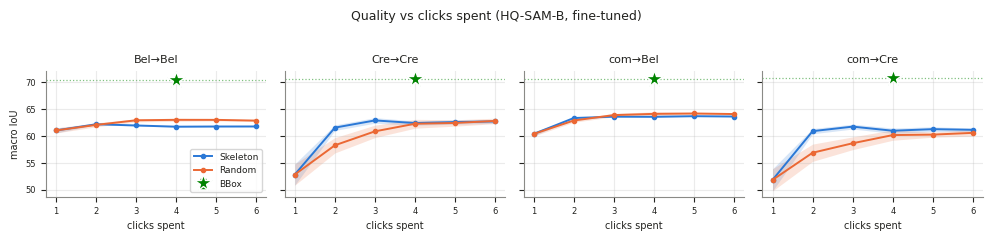

In [7]:
# Exp-3.1: quality vs clicks spent. The box is plotted at K=4 (its four coordinates), so the
# gap at K=4 compares 4 clicks with 1 box.
KS_DIR, KS_BB = BASE / "outputs/v14/ksweep", "hqsam_vit_b"
KS_CELLS = [("Belgium", "Belgium"), ("Crete", "Crete"), ("combined", "Belgium"), ("combined", "Crete")]
KS_VARIANTS = [("Skeleton", "skely"), ("Random", "random")]
KS_RANGE, BOX_K = [1, 2, 3, 4, 5, 6], 4

def _ks_key(v, K):
    return "click_1pt" if K == 1 else f"{v}_K{K}"

def ks_ms(reg, site, v, K):
    f = KS_DIR / f"v14ks_{reg}_on_{site}_{KS_BB}.json"
    if not f.exists():
        return (np.nan, 0.0)
    d = json.load(open(f))["strategies"].get(_ks_key(v, K), {})
    a = (list(d.get("overall_per_seed", [])) if METRIC == "micro"
         else [float(np.mean(list(s.values()))) for s in d.get("per_class_per_seed", []) if s])
    if not a:
        return (np.nan, 0.0)
    return (float(np.mean(a)), float(np.std(a, ddof=1)) if len(a) > 1 else 0.0)

drows, mrows, idx = [], [], []
for K in KS_RANGE:
    idx.append("1 (click)" if K == 1 else str(K)); drow, mrow = {}, {}
    for reg, site in KS_CELLS:
        dom = f"{reg[:3]}→{site[:3]}"
        for vl, v in KS_VARIANTS:
            mu, sd = ks_ms(reg, site, v, K)
            drow[(dom, vl)] = fmt_ms(mu, sd); mrow[(dom, vl)] = mu
        bmu, bsd = sam_ms(KS_BB, reg, site, "bbox_noisy") if K == BOX_K else (np.nan, 0.0)
        drow[(dom, "BBox")] = fmt_ms(bmu, bsd) if K == BOX_K else "–"
        mrow[(dom, "BBox")] = bmu
    drows.append(drow); mrows.append(mrow)
cols = pd.MultiIndex.from_tuples(list(drows[0].keys()), names=["train→eval", "prompt"])
e3d = pd.DataFrame(drows, index=pd.Index(idx, name="clicks spent")); e3d.columns = cols
e3m = pd.DataFrame(mrows, index=pd.Index(idx, name="clicks spent")).astype(float); e3m.columns = cols
display(style(e3d, 45, 75, gmap=e3m, fmt="{}", col_groups=True).apply(_bold_col_max(e3m), axis=0))

KS_COL = {"Skeleton": CAT["blue"], "Random": CAT["orange"], "BBox": "#008300"}
fig, axes = plt.subplots(1, len(KS_CELLS), figsize=(2.5 * len(KS_CELLS), 2.3), sharey=True)
for ax, (reg, site) in zip(np.atleast_1d(axes), KS_CELLS):
    for vl, v in KS_VARIANTS:
        mu = np.array([ks_ms(reg, site, v, K)[0] for K in KS_RANGE], float)
        sd = np.array([ks_ms(reg, site, v, K)[1] for K in KS_RANGE], float)
        ax.plot(KS_RANGE, mu, marker="o", ms=3, lw=1.4, color=KS_COL[vl], label=vl)
        ax.fill_between(KS_RANGE, mu - sd, mu + sd, color=KS_COL[vl], alpha=0.18, lw=0)
    b, bsd = sam_ms(KS_BB, reg, site, "bbox_noisy")
    if not np.isnan(b):
        ax.errorbar([BOX_K], [b], yerr=[bsd], color=KS_COL["BBox"], marker="*", ms=13,
                    mec="white", mew=1.0, lw=0, elinewidth=1.2, capsize=2.5, zorder=6, label="BBox")
        ax.axhline(b, color=KS_COL["BBox"], ls=":", lw=0.9, alpha=0.5, zorder=0)
    ax.set_title(f"{reg[:3]}→{site[:3]}", fontsize=8)
    ax.set_xlabel("clicks spent", fontsize=7); ax.set_xticks(KS_RANGE)
    ax.grid(alpha=0.25); ax.tick_params(labelsize=6)
np.atleast_1d(axes)[0].set_ylabel(f"{METRIC} IoU", fontsize=7)
np.atleast_1d(axes)[0].legend(fontsize=6.5, loc="lower right")
fig.suptitle("Quality vs clicks spent (HQ-SAM-B, fine-tuned)", y=1.02, fontsize=9)
fig.tight_layout()
plt.show()

#### 3.1b. K sweep on the v15 checkpoints (Table 4.3)

Section 3.1 reads `outputs/v14/ksweep`, an older HQ-SAM trained on the v12.1 schedule (cap 150,
stopped at epoch 50). This reruns the sweep on the v15 checkpoints (cap 300, stopped at epoch 100)
used everywhere else; data, split and prompt code are the same. The thesis uses the v15 numbers.

In [8]:
# Exp-3.1b: the K sweep on the v15 checkpoints (best_hq_58.pth), next to the v12.1-trained
# one from 3.1 (best_hq_30.pth). Same data, split and prompt code (prompt_version v14).
KS_NEW_BB = "hqsam_vit_b"
def ks_new(reg, site, v, K):
    s = _strat(KS_NEW_BB, reg, site, _ks_key(v, K), tag="_ks")
    per = [float(np.mean(list(x.values()))) for x in s.get("per_class_per_seed", []) if x]
    return float(np.mean(per)) if per else np.nan

rows, idx = [], []
for reg, site in KS_CELLS:
    for vl, v in KS_VARIANTS:
        idx.append(f"{reg[:3]}→{site[:3]} {vl}")
        r = {}
        for K in KS_RANGE:
            a, b = ks_ms(reg, site, v, K)[0], ks_new(reg, site, v, K)
            r[(str(K), "v12.1")], r[(str(K), "v15")] = f"{a:.1f}", f"{b:.1f}"
        rows.append(r)
t2 = pd.DataFrame(rows, index=idx); t2.columns = pd.MultiIndex.from_tuples(t2.columns)
print("Exp-3.1b · K sweep, macro IoU. Columns are clicks spent; v12.1 is the older checkpoint from 3.1.")
display(t2)

hi = sum(1 for reg, site in KS_CELLS for vl, v in KS_VARIANTS for K in KS_RANGE
         if ks_new(reg, site, v, K) > ks_ms(reg, site, v, K)[0])
tot = len(KS_CELLS) * len(KS_VARIANTS) * len(KS_RANGE)
print(f"v15 scores higher in {hi}/{tot} comparisons.")
print("\nREGIME READING, the reason this matters. Combined vs in-domain at Crete, random K6:")
for lab, fn in [("v12.1 (older)", lambda r, s: ks_ms(r, s, "random", 6)[0]),
                ("v15 (correct)", lambda r, s: ks_new(r, s, "random", 6))]:
    a, b = fn("Crete", "Crete"), fn("combined", "Crete")
    print(f"  {lab:15s} in-domain {a:.2f} vs combined {b:.2f}  ->  {b - a:+.2f}"
          f"{'  (combined WORSE)' if b - a < -0.59 else '  (tied, inside the 0.59 floor)'}")
print("So the claim moves from 'combined hurts at Crete' to 'combined is neutral at Crete and helps"
      "\nat Belgium, never hurts'.")


Exp-3.1b · K sweep, macro IoU. Columns are clicks spent; v12.1 is the older checkpoint from 3.1.


1           2           3           4           5        \
                 v12.1   v15 v12.1   v15 v12.1   v15 v12.1   v15 v12.1   v15   
Bel→Bel Skeleton  61.1  60.8  62.2  62.7  62.0  62.8  61.8  62.8  61.8  62.9   
Bel→Bel Random    61.1  60.8  62.1  62.4  62.9  63.5  63.0  63.8  63.0  64.0   
Cre→Cre Skeleton  52.8  53.8  61.6  62.9  62.9  63.8  62.4  63.5  62.6  63.8   
Cre→Cre Random    52.8  53.8  58.3  60.1  60.9  62.6  62.3  64.0  62.4  64.3   
com→Bel Skeleton  60.4  60.8  63.4  63.9  63.6  64.2  63.6  64.4  63.7  64.4   
com→Bel Random    60.4  60.8  62.9  63.6  63.9  65.1  64.1  65.4  64.2  65.5   
com→Cre Skeleton  51.8  54.7  60.9  62.6  61.8  63.8  61.0  63.6  61.3  63.9   
com→Cre Random    51.8  54.7  56.9  59.9  58.7  62.1  60.2  63.6  60.3  63.8   

                     6        
                 v12.1   v15  
Bel→Bel Skeleton  61.8  63.0  
Bel→Bel Random    62.9  64.0  
Cre→Cre Skeleton  62.7  63.9  
Cre→Cre Random    62.8  64.5  
com→Bel Skeleton  63.6  64.2  
com→Bel Random    64.1  65.5  
com→Cre Skeleton  61.2  64.0  
com→Cre Random    60.6  64.3

v15 scores higher in 46/48 comparisons.

REGIME READING, the reason this matters. Combined vs in-domain at Crete, random K6:
  v12.1 (older)   in-domain 62.83 vs combined 60.61  ->  -2.22  (combined WORSE)
  v15 (correct)   in-domain 64.45 vs combined 64.25  ->  -0.20  (tied, inside the 0.59 floor)
So the claim moves from 'combined hurts at Crete' to 'combined is neutral at Crete and helps
at Belgium, never hurts'.


#### 3.2 Which fauna gain, and which lose, from extra clicks?

Cells show the **change** in that class's IoU relative to the 1-click prompt, so 0 means the extra
clicks bought nothing. Blue = gained, red = lost. The colour scale diverges from zero because a
change has a true zero, unlike the raw IoU tables.

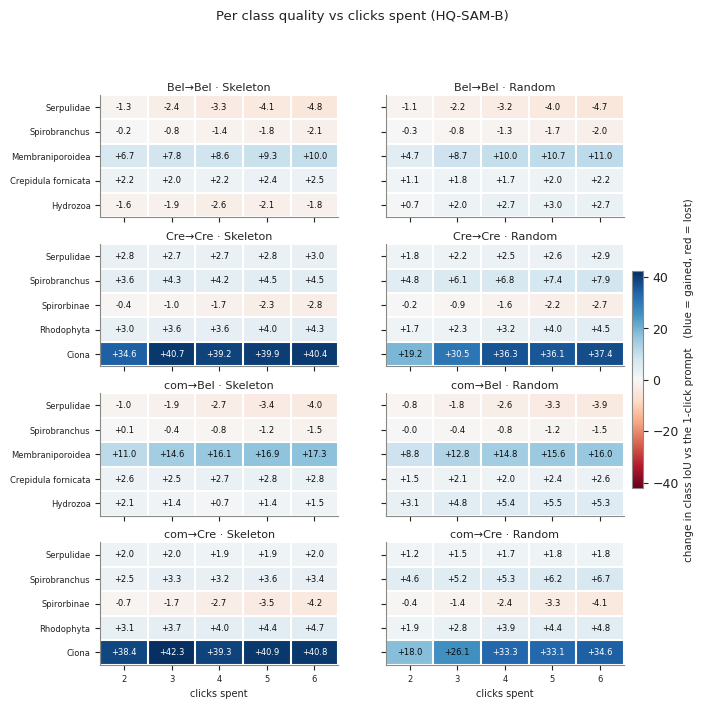

In [9]:
# Exp-3.2: per-class delta vs the 1-click prompt.
def ks_perclass(reg, site, v, K):
    f = KS_DIR / f"v14ks_{reg}_on_{site}_{KS_BB}.json"
    if not f.exists():
        return {}
    seeds = json.load(open(f))["strategies"].get(_ks_key(v, K), {}).get("per_class_per_seed", [])
    acc = defaultdict(list)
    for d in seeds:
        for k, val in d.items():
            acc[k].append(val)
    return {k: float(np.mean(vv)) for k, vv in acc.items()}

_KS = [K for K in KS_RANGE if K != 1]
_blocks, _vmax = {}, 0.0
for reg, site in KS_CELLS:
    for vl, v in KS_VARIANTS:
        base = ks_perclass(reg, site, v, 1)
        rows = [c for c in SITE_CLASSES[site] if c in base]
        Mx = np.full((len(rows), len(_KS)), np.nan)
        for j, K in enumerate(_KS):
            pc = ks_perclass(reg, site, v, K)
            for i, c in enumerate(rows):
                if c in pc and c in base:
                    Mx[i, j] = pc[c] - base[c]
        _blocks[(reg, site, vl)] = (Mx, rows)
        if Mx.size and not np.all(np.isnan(Mx)):
            _vmax = max(_vmax, float(np.nanmax(np.abs(Mx))))
_vmax = max(_vmax, 1e-6)

fig, axes = plt.subplots(len(KS_CELLS), len(KS_VARIANTS),
                         figsize=(3.5 * len(KS_VARIANTS), 1.85 * len(KS_CELLS)), squeeze=False)
fig.subplots_adjust(hspace=0.22)
im = None
for r, (reg, site) in enumerate(KS_CELLS):
    for c, (vl, v) in enumerate(KS_VARIANTS):
        ax = axes[r][c]; Mx, rows = _blocks[(reg, site, vl)]
        im = ax.imshow(Mx, cmap="RdBu", vmin=-_vmax, vmax=_vmax, aspect="auto")
        ax.set_xticks(range(len(_KS)))
        ax.set_xticklabels(_KS if r == len(KS_CELLS) - 1 else ["" for _ in _KS], fontsize=6)
        ax.set_yticks(range(len(rows)))
        ax.set_yticklabels(rows if c == 0 else ["" for _ in rows], fontsize=6)
        for i in range(Mx.shape[0]):
            for j in range(Mx.shape[1]):
                if not np.isnan(Mx[i, j]):
                    ax.text(j, i, f"{Mx[i, j]:+.1f}", ha="center", va="center", fontsize=6,
                            color="white" if abs(Mx[i, j]) > 0.62 * _vmax else "#0b0b0b")
        ax.set_title(f"{reg[:3]}→{site[:3]} · {vl}", fontsize=8, pad=3)
        if r == len(KS_CELLS) - 1:
            ax.set_xlabel("clicks spent", fontsize=7)
        ax.set_xticks(np.arange(-.5, len(_KS), 1), minor=True)
        ax.set_yticks(np.arange(-.5, len(rows), 1), minor=True)
        ax.grid(which="minor", color="white", lw=1.5); ax.tick_params(which="minor", length=0)
cb = fig.colorbar(im, ax=axes, fraction=0.02, pad=0.015)
cb.set_label("change in class IoU vs the 1-click prompt   (blue = gained, red = lost)", fontsize=7.5)
fig.suptitle("Per class quality vs clicks spent (HQ-SAM-B)", y=0.995, fontsize=9.5)
plt.show()

#### 3.3 Iterative prompt process (with and without prompt)

| | |
|---|---|
| **IoU@K** | mean IoU after K rounds of correction, instance-pooled (**micro**), as `iou_at_K` is stored. |
| **NoC@X** | *Number of Clicks* to first reach X% IoU **on that instance**, averaged; 21 if never reached. |
| **NoF@X** | *Number of Failures*, the fraction of instances that never reach X% within the 20-click budget. |
| **ms/round** | model time for one correction click: a single decoder pass on an already-encoded tile, averaged over rounds 2 to 20. The image encoder is excluded because it runs once per tile (~108 ms HQ-SAM, ~98 ms SegNext) and is amortised over every object on it. |

Read NoC together with NoF: NoC 20.9 with NoF 1.00 doesn't mean 21 clicks, it means nothing reached
the target. **NoF@85 never drops below 0.52**; most ARMS objects never reach 85% IoU, because they
are only a few hundred pixels.

In [10]:
# Exp-3.3: the iterative reference table -- IoU at 1/10/20 clicks, NoC/NoF at 85 and 90,
# and the model cost of one correction click. Latency comes from the pinned-GPU benchmark.
E3_MODELS = [("HQ-SAM-B", "hqsam_vit_b"), ("SegNext", "segnext")]
LAT_KEY = {"hqsam_vit_b": "hqsam", "segnext": "segnext"}

def _ms_round(bb, site, neg):
    """ms for one correction click, cached tile. Zero-shot file serves both states: the
    decoder shape is unchanged by fine-tuning."""
    f = BASE / f"outputs/v15/latency/{LAT_KEY.get(bb,'')}_zero_{site}.json"
    if not f.exists():
        return np.nan
    return json.load(open(f))["iterative"]["neg_on" if neg else "neg_off"]["ms_per_round_cached"]


# ---- seed spread for IoU@K ---------------------------------------------------------------------
# iou_at_K was stored as one averaged value per K, so K2..K19 have no per-seed spread (measuring
# it would mean re-running the iterative evals, ~64 GPU h). The two ends do:
#   K=1   the one-pass click_1pt run, with its own ten seeds (it matches the iterative K1 value
#         to within 0.07)
#   K=20  the strategy's `mean` is the K20 point and `overall_per_seed` holds the ten draws
# In between the spread is interpolated linearly and marked ~. A slope-based rule was tried and
# dropped: fitted at the two ends it gave very different slopes (0.202 vs 0.029).
def _onepass_sd(bb, reg, site):
    """First-click spread, from the matched one-pass run."""
    return _strat(bb, reg, site, "click_1pt").get("std", np.nan)

def iter_sd(bb, reg, site, tag, K):
    """(sd, is_measured) at click K. Measured at K=20, read off the one-pass run at K=1,
    linearly interpolated in between."""
    d = _strat(bb, reg, site, "iter_K20", tag)
    sd1, sd20 = _onepass_sd(bb, reg, site), d.get("std", np.nan)
    if K == 20 and np.isfinite(sd20):
        return (sd20, True)
    if not (np.isfinite(sd1) and np.isfinite(sd20)):
        return (sd1 if K == 1 else np.nan, False)
    return (sd1 + (sd20 - sd1) * (K - 1) / 19.0, False)

rows, drows = [], []
for lbl, bb in E3_MODELS:
    for state, regf in [("zero-shot", lambda s: "zero"), ("fine-tuned", lambda s: s)]:
        for site in SITES:
            r = {"model": lbl, "state": state, "site": site}
            dsp = {"model": lbl, "state": state, "site": site}
            for tag, nm, neg in [("_it", "neg OFF", False), ("_itneg", "neg ON", True)]:
                d = _strat(bb, regf(site), site, "iter_K20", tag)
                io = d.get("iou_at_K") or {}
                # IoU@20's spread comes from overall_per_seed (its `mean` is the K20 point);
                # K1 and K10 only have the averaged value
                for k in (1, 10, 20):
                    v = io.get(f"K{k}", np.nan)
                    r[(nm, f"IoU@{k}")] = v
                    if not np.isfinite(v):
                        dsp[(nm, f"IoU@{k}")] = "–"
                    else:
                        sd, meas = iter_sd(bb, regf(site), site, tag, k)
                        dsp[(nm, f"IoU@{k}")] = (f"{v:.2f}" if not np.isfinite(sd) else
                                                 f"{v:.2f}±{sd:.2f}" if meas else
                                                 f"{v:.2f}~{sd:.2f}")
                # NoC and NoF have a stored seed std (NoC@X_std, NoF@X_std); IoU@K does not
                for t in (85, 90):
                    for pre, dec in (("NoC", 2), ("NoF", 3)):
                        mu, sd = d.get(f"{pre}@{t}", np.nan), d.get(f"{pre}@{t}_std", np.nan)
                        r[(nm, f"{pre}@{t}")] = mu
                        dsp[(nm, f"{pre}@{t}")] = ("–" if not np.isfinite(mu) else
                                                   f"{mu:.{dec}f}" if not np.isfinite(sd)
                                                   else f"{mu:.{dec}f}±{sd:.{dec}f}")
                ms = _ms_round(bb, site, neg)
                r[(nm, "ms/round")] = ms
                dsp[(nm, "ms/round")] = "–" if not np.isfinite(ms) else f"{ms:.2f}"
            rows.append(r); drows.append(dsp)
nn = pd.DataFrame(rows).set_index(["model", "state", "site"])
nn.columns = pd.MultiIndex.from_tuples(nn.columns, names=["negatives", "metric"])
dd33 = pd.DataFrame(drows).set_index(["model", "state", "site"])
dd33.columns = pd.MultiIndex.from_tuples(dd33.columns, names=["negatives", "metric"])
dd33 = dd33[nn.columns]
nof_cols = [c for c in nn.columns if c[1].startswith("NoF")]
iou_cols = [c for c in nn.columns if c[1].startswith("IoU")]
ms_cols = [c for c in nn.columns if c[1] == "ms/round"]
# the displayed frame holds strings, so each gradient takes gmap from the numeric copy
# (axis=None is needed with a DataFrame gmap)
display(dd33.style.format("{}", na_rep="–")
        .background_gradient(cmap=GRAD + "_r", subset=nof_cols, gmap=nn[nof_cols], axis=None, vmin=0.4, vmax=1.0)
        .background_gradient(cmap=GRAD, subset=iou_cols, gmap=nn[iou_cols], axis=None, vmin=5, vmax=80)
        .background_gradient(cmap=GRAD + "_r", subset=ms_cols, gmap=nn[ms_cols], axis=None, vmin=5, vmax=70)
        .set_table_styles(_col_borders(nn), overwrite=False)
        .set_caption("Iterative segmentation: quality at 1 / 10 / 20 clicks, the per-instance cost, "
                     "and the model time per correction. Green NoF = fewer failures. NoC 21 = censored. "
                     "± is a measured 10-seed spread, ~ is estimated from the curve slope."))
print("IoU@K spread: ± measured (K20 from overall_per_seed, K1 from the matched one-pass run), "
      "~ interpolated between those two anchors.")

IoU@K spread: ± measured (K20 from overall_per_seed, K1 from the matched one-pass run), ~ interpolated between those two anchors.


#### 3.4 Iterative correction, zero-shot vs fine-tuned

Iterative protocol only: each line goes from click 1 to click 20, adding one correction click per
round on the model's largest error, with negative clicks allowed. **Micro IoU**, as stored in
`iou_at_K`. Dashed lines are zero-shot, solid lines fine-tuned (Figure 4.3).

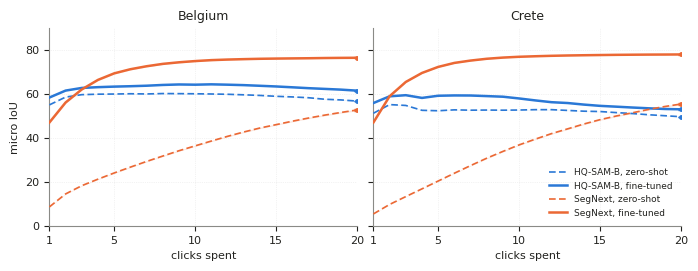

In [11]:
# Exp-3.4: iterative curves, one panel per evaluation site.
# dashed = zero-shot, solid = fine-tuned, colour = model
import subprocess, matplotlib

ITER_SER = [("hqsam_vit_b", "HQ-SAM-B", CAT["blue"]), ("segnext", "SegNext", CAT["orange"])]
ITER_TAG = "_itneg"        # iterative runs with negative clicks on

# drawn at the printed size: in a .pdf_tex the drawing is scaled but LaTeX sets the text
# at the document size, so a larger figure would come out with oversized labels
FIG_W, FIG_H = 6.87, 2.6   # 6.87in = \textwidth (496.86pt); use 3.28 for \columnwidth
FONT_PT = 8                # matches \footnotesize at a 10pt base

def curve(bb, reg, site, tag=ITER_TAG):
    d = (_strat(bb, reg, site, "iter_K20", tag).get("iou_at_K") or {})
    return [d.get(f"K{k}", np.nan) for k in range(1, 21)]

def endpoint_sd(bb, reg, site, tag=ITER_TAG):
    """Seed spread at K=20, the only point on the curve that still has a per-seed record.
    `iou_at_K` was written as one averaged scalar per K, so K1 to K19 cannot be given a band
    without re-running the iterative evals. The strategy's `mean` IS the K20 value and
    `overall_per_seed` holds the ten draws behind it, so the endpoint can. It is drawn as a
    marker with a bar rather than a ribbon, to avoid implying a band the other points do not
    have. Every line is a ten-seed mean regardless."""
    return _strat(bb, reg, site, "iter_K20", tag).get("std", np.nan)

with plt.rc_context({"font.size": FONT_PT}):
    fig, axes = plt.subplots(1, 2, figsize=(FIG_W, FIG_H), sharey=True)
    for ax, site in zip(axes, SITES):
        for bb, lbl, col in ITER_SER:
            for state, ls, lw in [("zero-shot", (0, (4, 2)), 1.2), ("fine-tuned", "-", 1.8)]:
                reg = "zero" if state == "zero-shot" else site
                y = curve(bb, reg, site)
                if np.all(np.isnan(y)):
                    continue
                ax.plot(range(1, 21), y, color=col, ls=ls, lw=lw, zorder=3,
                        label=f"{lbl}, {state}")
                # seed-spread envelope: measured at K=1 and K=20, interpolated between (see 3.3);
                # drawn faintly, and at this scale it is barely wider than the line
                sds = np.array([iter_sd(bb, reg, site, ITER_TAG, k)[0]
                                for k in range(1, 21)], float)
                if np.isfinite(sds).any():
                    ax.fill_between(range(1, 21), np.array(y) - sds, np.array(y) + sds,
                                    color=col, alpha=.16, lw=0, zorder=2)
                sd = endpoint_sd(bb, reg, site)
                if np.isfinite(sd) and np.isfinite(y[-1]):
                    ax.errorbar([20], [y[-1]], yerr=[sd], color=col, elinewidth=1.0,
                                capsize=2.0, marker="o", ms=2.5, lw=0, zorder=4)
        ax.set_title(site, fontsize=FONT_PT + 1, loc="center")
        ax.grid(alpha=.3, ls=":", lw=.5); ax.set_xticks([1, 5, 10, 15, 20])
        ax.set_xlim(1, 20); ax.set_ylim(0, 90); ax.set_xlabel("clicks spent")
        for s in ("top", "right"):
            ax.spines[s].set_visible(False)
    axes[0].set_ylabel("micro IoU")
    axes[1].legend(fontsize=FONT_PT - 1.5, frameon=False, loc="lower right")
    fig.tight_layout(pad=.4)

# save_pdf_tex(fig, "iter_curves")    # -> thesis/figures/iter_curves.pdf{,_tex}
plt.show()


## Automatic Detector Models

The interactive models above segment whatever you point at. They have no classification head, so
they never say what a thing is. The detectors do both jobs at once: find the object and name it.

Because a detector can only emit one of the classes it was trained on, anything outside that list is
unreachable by construction. A prompted model has no label set, so nothing is unreachable. Label
granularity is therefore a design choice that exists only on this side.

Metric is matched mask IoU: for each ground truth instance take the best overlapping prediction of
the same class, each prediction usable once, unmatched ground truth scores zero. Same frozen plate
split as everywhere else. Detector run-to-run noise is about 5.8 matched IoU, so smaller
differences aren't meaningful.

### 5. Automatic detector performance (indo/cross/comb)

Species labels. Rows are train site to eval site. Bold marks the best model in each column.

*native: YOLO = 640 square · Mask R-CNN = detectron2 multi-scale short side 640-800*

The second table adds **mAP**, each framework's own metric, so the detectors can be read against
the detection literature as well as against the prompted models. It is shown at 1024 only, the
setting the thesis reports. mAP cannot be computed for the interactive models, so it cannot serve as
the shared axis; matched IoU does that job. See `det_map` for why.


In [14]:
# Exp-5: architecture x input size, species labels.
idx = [f"{r[:3]}→{s[:3]}" for r, s in XEVAL_ORDER]
dat = [{(lbl, nm): det("species", a, r, s, z) for lbl, a in ARCHS for nm, z in SIZES}
       for r, s in XEVAL_ORDER]
t5 = pd.DataFrame(dat, index=idx)
t5.columns = pd.MultiIndex.from_tuples(t5.columns, names=["arch", "input"])
t5.index.name = "train → eval"
display(style(t5, 0, 50, col_groups=True, split_row=[4]).apply(_bold_col_max(t5), axis=0))
# mAP at 1024, the framework's own number from the `native` block. It agrees closely with
# matched IoU (r = 0.95 over these 18 cells).
MAP_COLS = [("mAP50-95", "mAP"), ("mAP50", "AP50"), ("matched IoU", None)]
dm = [{(lbl, nm): (det("species", a, r, s_, 1024) if fld is None
                   else det_map("species", a, r, s_, 1024, fld))
       for lbl, a in ARCHS for nm, fld in MAP_COLS}
      for r, s_ in XEVAL_ORDER]
t5m = pd.DataFrame(dm, index=idx)
t5m.columns = pd.MultiIndex.from_tuples(t5m.columns, names=["arch", "metric"])
t5m.index.name = "train → eval"
display(style(t5m, 0, 50, col_groups=True, split_row=[4]).apply(_bold_col_max(t5m), axis=0))

_p = [(det_map("species", a, r, s_, 1024), det("species", a, r, s_, 1024))
      for _, a in ARCHS for r, s_ in XEVAL_ORDER]
_p = [(x, y) for x, y in _p if not (np.isnan(x) or np.isnan(y))]
print(f"mAP50-95 vs matched IoU, {len(_p)} cells: Pearson r = "
      f"{np.corrcoef([x for x, _ in _p], [y for _, y in _p])[0, 1]:.3f}")


mAP50-95 vs matched IoU, 18 cells: Pearson r = 0.896


#### 5b. Detectors at a uniform 0.5 confidence floor (Tables 4.5 and 4.6)

YOLO was first scored at Ultralytics' default `conf=0.25` while Mask R-CNN's predictions were written
at `SCORE_THRESH_TEST=0.5`, so YOLO had more candidates to match. Both are now at 0.5; Mask R-CNN is
unchanged and serves as the control. The thesis uses the 0.5 numbers.

In [15]:
# Exp-5b: detectors before vs after the uniform 0.5 confidence floor. YOLO was scored at
# Ultralytics' default 0.25, giving the matcher about twice as many candidates as Mask R-CNN
# (written at 0.5); since matched IoU has no false-positive penalty, that favoured YOLO.
# Mask R-CNN doesn't change and is the control.
DET_OLD = V15 / "_superseded/yolo_conf025"
def det_old(space, arch, reg, site, imgsz=1024):
    suf = "" if imgsz == 640 else f"_i{imgsz}"
    if arch == "maskrcnn":
        return det(space, arch, reg, site, imgsz)          # never rescored, by construction
    root = "taskB" if space == "species" else "taskB_phylum"
    f = DET_OLD / root / f"{arch}_{reg}{suf}" / f"metrics_{site}.json"
    if not f.exists():
        return np.nan
    per = json.load(open(f))["strategies"]["automatic"].get("per_class", {})
    return float(np.mean([c["iou"] for c in per.values()])) if per else np.nan

for imgsz, szlab in [(1024, "@1024"), (640, "native")]:
    rows, idx, flips = [], [], 0
    for reg, site in XEVAL_ORDER:
        idx.append(f"{reg[:3]}→{site[:3]}")
        r, o, n = {}, {}, {}
        for lbl, a in ARCHS:
            o[lbl], n[lbl] = det_old("species", a, reg, site, imgsz), det("species", a, reg, site, imgsz)
            r[(lbl, "before")], r[(lbl, "after")] = f"{o[lbl]:.2f}", f"{n[lbl]:.2f}"
        wo, wn = max(o, key=o.get), max(n, key=n.get)
        gap = n[wn] - sorted(n.values())[-2]
        r[("best", "before")], r[("best", "after")] = wo, wn
        # 5.78 = detector noise floor (same config retrained, mean |diff|)
        r[("best", "margin")] = f"{gap:.1f}" + ("" if gap > 5.78 else " (tie)")
        flips += wo != wn
        rows.append(r)
    t = pd.DataFrame(rows, index=idx); t.columns = pd.MultiIndex.from_tuples(t.columns)
    print(f"Exp-5b · species matched IoU {szlab}. Mask R-CNN is the control and must not move.")
    display(t)
    print(f"  best-architecture ranking flips in {flips}/6 cells at {szlab}; "
          f"'(tie)' marks a margin inside the 5.78 detector noise floor.\n")
print("At the default 0.25, YOLO11s looked best in every regime. At the shared 0.5 threshold that\n"
      "no longer holds, so YOLO11s is used for the phylum experiment for its speed, not its IoU.")


Exp-5b · species matched IoU @1024. Mask R-CNN is the control and must not move.


YOLO11s        YOLO26s        Mask R-CNN            best              \
         before  after  before  after     before  after   before       after   
Bel→Bel   40.56  27.50   38.78  28.56      37.59  37.59  YOLO11s  Mask R-CNN   
Cre→Bel    5.72   2.92    4.71   2.21       4.60   4.60  YOLO11s  Mask R-CNN   
com→Bel   44.97  33.93   38.18  26.33      29.85  29.85  YOLO11s     YOLO11s   
Cre→Cre   37.97  21.32   35.18  17.05      32.53  32.53  YOLO11s  Mask R-CNN   
Bel→Cre    2.83   1.89    0.05   0.00       2.73   2.73  YOLO11s  Mask R-CNN   
com→Cre   43.57  28.28   35.56  20.08      30.59  30.59  YOLO11s  Mask R-CNN   

                    
            margin  
Bel→Bel        9.0  
Cre→Bel  1.7 (tie)  
com→Bel  4.1 (tie)  
Cre→Cre       11.2  
Bel→Cre  0.8 (tie)  
com→Cre  2.3 (tie)

  best-architecture ranking flips in 5/6 cells at @1024; '(tie)' marks a margin inside the 5.78 detector noise floor.

Exp-5b · species matched IoU native. Mask R-CNN is the control and must not move.


YOLO11s        YOLO26s        Mask R-CNN            best              \
         before  after  before  after     before  after   before       after   
Bel→Bel   37.19  28.64   31.87  21.51      35.37  35.37  YOLO11s  Mask R-CNN   
Cre→Bel    7.31   3.46    6.78   4.78       3.31   3.31  YOLO11s     YOLO26s   
com→Bel   38.71  25.43   33.78  20.49      33.74  33.74  YOLO11s  Mask R-CNN   
Cre→Cre   32.87  19.82   33.63  24.73      31.10  31.10  YOLO26s  Mask R-CNN   
Bel→Cre    1.86   0.71    2.38   1.47       2.30   2.30  YOLO26s  Mask R-CNN   
com→Cre   42.94  27.97   34.24  19.17      36.80  36.80  YOLO11s  Mask R-CNN   

                    
            margin  
Bel→Bel        6.7  
Cre→Bel  1.3 (tie)  
com→Bel        8.3  
Cre→Cre        6.4  
Bel→Cre  0.8 (tie)  
com→Cre        8.8

  best-architecture ranking flips in 6/6 cells at native; '(tie)' marks a margin inside the 5.78 detector noise floor.

At the default 0.25, YOLO11s looked best in every regime. At the shared 0.5 threshold that
no longer holds, so YOLO11s is used for the phylum experiment for its speed, not its IoU.


### 5.1 per-class performance (species level)

In [16]:
# Exp-5.1: per-class IoU by architecture and training condition, species labels, 1024 input
# (at 1024 all three frameworks see the tile unchanged)
rows51, idx51 = [], []
for site in SITES:
    per = {(lbl, c): det_cond("species", a, site, c) for lbl, a in ARCHS for c in CONDS}
    classes = [k for k in det_cond("species", "yolo11s-seg", site, "indo")]
    for cls in classes:
        n = next((v[1] for d in per.values() for k, v in d.items() if k == cls), 0)
        idx51.append((site, cls, n))
        rows51.append({(lbl, c): per[(lbl, c)].get(cls, (np.nan, 0))[0]
                     for lbl, _ in ARCHS for c in CONDS})
    idx51.append((site, "macro mean", ""))
    rows51.append({(lbl, c): float(np.nanmean([per[(lbl, c)].get(k, (np.nan, 0))[0] for k in classes]))
                 for lbl, _ in ARCHS for c in CONDS})
t51 = pd.DataFrame(rows51, index=pd.MultiIndex.from_tuples(idx51, names=["site", "class", "n"]))
t51.columns = pd.MultiIndex.from_tuples(t51.columns, names=["arch", "train"])
display(style(t51, 0, 85, col_groups=True, row_groups=True))

### 6. Species vs Phylum level (long tail problem)

Same architecture, same images, same split. Only the label space changes. Coarsening merges 24
species into 5 phyla at Belgium and 36 into 5 at Crete, and it also admits instances whose species
was not in the 8 class list, so the phylum test set is larger: 1353 against 1266 at Belgium, 2718
against 2595 at Crete.

The two columns are therefore not scored on the same instances. Phylum is graded on the larger and
harder set and still scores higher, so the gain is real, but it mixes better coverage with a change
of denominator.

In [17]:
# Exp-6: species vs phylum, YOLO11s only (the phylum runs were trained for that arch).
rows = []
for r, s in XEVAL_ORDER:
    rows.append({(sp, nm): det(sp, "yolo11s-seg", r, s, z)
                 for sp in ("species", "phylum") for nm, z in SIZES})
t6 = pd.DataFrame(rows, index=[f"{r[:3]}→{s[:3]}" for r, s in XEVAL_ORDER])
t6.columns = pd.MultiIndex.from_tuples(t6.columns, names=["labels", "input"])
t6.index.name = "train → eval"
display(style(t6, 0, 50, col_groups=True, split_row=[4]))

#### 6b. Phylum classes matched by name (Table 4.7)

The three training regimes use different phylum label orders, but every checkpoint was first scored
against the evaluation site's labels by index, so only index 0 (Annelida) lined up. Predictions are
now matched by class name. The two in-domain cells were always correct and serve as the control.

In [18]:
# Exp-6b: phylum before vs after matching classes by name. The v15 runs numbered the phyla
# of each regime separately:
#   Belgium  0 Annelida 1 Arthropoda 2 Bryozoa 3 Cnidaria  4 Mollusca
#   Crete    0 Annelida 1 Bryozoa    2 Chordata 3 Mollusca 4 Rhodophyta
#   combined 0 Annelida 1 Arthropoda 2 Bryozoa 3 Chordata  4 Cnidaria 5 Mollusca 6 Rhodophyta
# Matching by index only lined up Annelida, which is 1166 of Belgium's 1353 test instances, so
# the wrong numbers looked plausible. The in-domain cells are the control.
PH_OLD = V15 / "_superseded/yolo_phylum_noremap"
def ph_old(reg, site, imgsz=1024):
    suf = "" if imgsz == 640 else f"_i{imgsz}"
    f = PH_OLD / f"yolo11s-seg_{reg}{suf}" / f"metrics_{site}.json"
    if not f.exists():
        return np.nan
    per = json.load(open(f))["strategies"]["automatic"].get("per_class", {})
    return float(np.mean([c["iou"] for c in per.values()])) if per else np.nan
def ph_flag(reg, site, imgsz, key):
    suf = "" if imgsz == 640 else f"_i{imgsz}"
    f = V15 / "taskB_phylum/yolo" / f"yolo11s-seg_{reg}{suf}" / f"metrics_{site}.json"
    return json.load(open(f))["strategies"]["automatic"].get(key) if f.exists() else None

rows, idx = [], []
for reg, site in XEVAL_ORDER:
    idx.append(f"{reg[:3]}→{site[:3]}")
    r = {}
    for imgsz, szl in [(1024, "@1024"), (640, "native")]:
        a, b = ph_old(reg, site, imgsz), det("phylum", "yolo11s-seg", reg, site, imgsz)
        r[(szl, "before")], r[(szl, "after")], r[(szl, "Δ")] = f"{a:.2f}", f"{b:.2f}", f"{b - a:+.2f}"
    r[("check", "maps agree")] = str(ph_flag(reg, site, 1024, "label_map_matches"))
    r[("check", "remapped")] = str(ph_flag(reg, site, 1024, "label_remap_applied"))
    rows.append(r)
t = pd.DataFrame(rows, index=idx); t.columns = pd.MultiIndex.from_tuples(t.columns)
print("Exp-6b · phylum, YOLO11s matched IoU. In-domain rows are the control: maps already agreed,\n"
      "so the remap is skipped and the number must not move.")
display(t)
print("CONTROL: in-domain Δ must be ~0 (only GPU nondeterminism); cross-site rows are the fix.")
for reg, site in [("Belgium", "Belgium"), ("Crete", "Crete")]:
    print(f"  {reg[:3]}→{site[:3]}  Δ = {det('phylum','yolo11s-seg',reg,site,1024) - ph_old(reg,site,1024):+.3f}")
print("\nCOMBINED vs IN-DOMAIN after matching by name, @1024:")
ind_b, com_b = det("phylum", "yolo11s-seg", "Belgium", "Belgium", 1024), det("phylum", "yolo11s-seg", "combined", "Belgium", 1024)
ind_c, com_c = det("phylum", "yolo11s-seg", "Crete", "Crete", 1024), det("phylum", "yolo11s-seg", "combined", "Crete", 1024)
print(f"  combined {com_b:.2f} vs in-domain {ind_b:.2f} at Belgium ({com_b-ind_b:+.2f}),")
print(f"  combined {com_c:.2f} vs in-domain {ind_c:.2f} at Crete   ({com_c-ind_c:+.2f}).")
print("  Both gaps are inside the 5.78 detector noise floor, so combined training is on par with")
print("  in-domain training. Matched by index, combined looked far worse.")


Exp-6b · phylum, YOLO11s matched IoU. In-domain rows are the control: maps already agreed,
so the remap is skipped and the number must not move.


@1024                native                     check         
        before  after       Δ before  after       Δ maps agree remapped
Bel→Bel  36.32  36.32   +0.00  37.56  37.56   +0.00       True    False
Cre→Bel   5.21  10.09   +4.88  10.97  16.90   +5.93      False     True
com→Bel  14.74  38.18  +23.45  19.22  39.97  +20.75      False     True
Cre→Cre  28.50  28.50   +0.00  34.39  34.39   +0.00       True    False
Bel→Cre   0.45   1.08   +0.63   0.42   1.13   +0.71      False     True
com→Cre   9.21  31.74  +22.52  10.21  31.61  +21.40      False     True

CONTROL: in-domain Δ must be ~0 (only GPU nondeterminism); cross-site rows are the fix.
  Bel→Bel  Δ = +0.002
  Cre→Cre  Δ = +0.000

COMBINED vs IN-DOMAIN after matching by name, @1024:
  combined 38.18 vs in-domain 36.32 at Belgium (+1.86),
  combined 31.74 vs in-domain 28.50 at Crete   (+3.24).
  Both gaps are inside the 5.78 detector noise floor, so combined training is on par with
  in-domain training. Matched by index, combined looked far worse.


### 6.1 per-class performance (species vs phylum level)

In [19]:
# Exp-6.1: per-class IoU under each label space, YOLO11s, 1024 input. The label spaces don't
# share classes, so they are stacked as separate blocks; n differs because phylum labels
# include instances that had no species class.
rows61, idx61 = [], []
for site in SITES:
    for space in ("species", "phylum"):
        per = {c: det_cond(space, "yolo11s-seg", site, c) for c in CONDS}
        classes = list(per["indo"])
        for cls in classes:
            idx61.append((site, space, cls, per["indo"][cls][1]))
            rows61.append({c: per[c].get(cls, (np.nan, 0))[0] for c in CONDS})
        idx61.append((site, space, "macro mean", sum(per["indo"][k][1] for k in classes)))
        rows61.append({c: float(np.nanmean([per[c].get(k, (np.nan, 0))[0] for k in classes]))
                     for c in CONDS})
t61 = pd.DataFrame(rows61, index=pd.MultiIndex.from_tuples(idx61, names=["site", "labels", "class", "n"]))
display(style(t61, 0, 85, row_groups=True))

#### What the two label spaces contain, and what coarsening buys

Derived from `experiments/manifests_{v11,phylum}/<site>/raw.json`. Both label spaces use the same plate split: identical plate ids in train, val and test, and no plate in two splits. Only the label set and the in-scope annotations differ, which is why the phylum column is graded on a larger set.

| site | labels | class | train | val | test | combines |
|---|---|---|---|---|---|---|
| Belgium | species | Serpulidae | 1506 | 363 | 618 | |
|  |  | Spirobranchus | 1173 | 263 | 522 | |
|  |  | Membraniporoidea | 167 | 34 | 64 | |
|  |  | Crepidula fornicata | 87 | 22 | 36 | |
|  |  | Hydrozoa | 63 | 17 | 26 | |
| | **species total** | **5 classes** | **2996** | **699** | **1266** | |
| | phylum | Annelida | 2729 | 637 | 1166 | 5 species: Serpulidae, Spirobranchus, Lanice conchilega, +2 more |
| |  | Bryozoa | 199 | 46 | 76 | 2 species: Membraniporoidea, Bryozoa |
| |  | Cnidaria | 138 | 38 | 58 | 4 species: Hydrozoa, Actiniidae, Metridium, +1 more |
| |  | Mollusca | 93 | 25 | 38 | 7 species: Crepidula fornicata, Bivalvia, Mytilus, +4 more |
| |  | Arthropoda | 88 | 11 | 15 | 6 species: Crustacea, Jassa, Brachyura, +3 more |
| | **phylum total** | **5 classes** | **3247** | **757** | **1353** | **24 species grouped, +8% training instances** |
| Crete | species | Serpulidae | 1096 | 273 | 454 | |
|  |  | Spirobranchus | 75 | 17 | 30 | |
|  |  | Spirorbinae | 4998 | 1148 | 1951 | |
|  |  | Rhodophyta | 344 | 91 | 145 | |
|  |  | Ciona | 33 | 9 | 15 | |
| | **species total** | **5 classes** | **6546** | **1538** | **2595** | |
| | phylum | Annelida | 6261 | 1450 | 2462 | 11 species: Spirorbinae, Serpulidae, Spirobranchus, +8 more |
| |  | Rhodophyta | 348 | 91 | 150 | 2 species: Rhodophyta, Hildenbrandia rubra |
| |  | Mollusca | 103 | 26 | 57 | 13 species: Mimachlamys varia, Isognomon, Mollusca, +10 more |
| |  | Chordata | 105 | 36 | 39 | 9 species: Ciona, Ascidia mentula, Ascidiacea, +6 more |
| |  | Bryozoa | 27 | 9 | 10 | 1 species: Bryozoa |
| | **phylum total** | **5 classes** | **6844** | **1612** | **2718** | **36 species grouped, +5% training instances** |

Three things the table shows. Coarsening buys little data, +8% training instances at Belgium and +5% at Crete, which is modest for the size of the change to the label space. The two sites do not share a phylum set: Belgium has Cnidaria and Arthropoda, Crete has Rhodophyta and Chordata, and only Annelida, Bryozoa and Mollusca appear at both, so a cross-site phylum column still compares partly different label spaces. And Annelida dominates, 4532 of 5357 instances at Belgium and 10173 of 11174 at Crete, so the phylum macro is one very large class plus four small ones.

When recomputing this: `target_classes` in a phylum manifest is parallel to `target_cat_ids`, not a class list, so the species to phylum map is `zip()` of those two. `category_remap` maps a COCO category id to the phylum *class index*, and using it as an index into `target_classes` yields a scrambled mapping that still looks plausible, Serpulidae into Cnidaria and Crepidula into Arthropoda.
